## Testing toroid trasformation

testing the function to mapping the points inside a toroid to $R^3$

In [12]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [13]:
def map_torus_to_r3(point, inner_radius_a, outer_radius_b):
    """
    Maps a point from the interior of a torus to R^3.

    Args:
        point (tuple or list): The (x, y, z) coordinates of the point inside the torus.
        inner_radius_a (float): The inner radius of the torus.
        outer_radius_b (float): The outer radius of the torus.

    Returns:
        numpy.ndarray: The transformed (x', y', z') coordinates in R^3.
    """
    x, y, z = point

    # 1. Calculate the major and minor radii of the torus
    R = (inner_radius_a + outer_radius_b) / 2.0
    r = (outer_radius_b - inner_radius_a) / 2.0

    # Handle the case where the point is on the z-axis to avoid division by zero
    r_xy = np.sqrt(x**2 + y**2)
    if r_xy == 0:
        # If the point is on the z-axis, its projection on the xy-plane is the origin.
        # We can define the corresponding point C on the central circle to be (R, 0, 0).
        C = np.array([R, 0, 0])
    else:
        # 2. Find the corresponding point C on the central circle (in the xy-plane)
        C = np.array([R * x / r_xy, R * y / r_xy, 0])

    # 3. Determine the position vector V within the cross-section
    P = np.array([x, y, z])
    V = P - C

    # 4. Calculate the distance 's' of the point from the central circle
    s = np.linalg.norm(V)

    # If the point is on the central circle, it does not move.
    if s == 0:
        return P

    # 5. Define the scaling function to map the distance to infinity
    # This stretches the distance from the range [0, r) to [0, infinity)
    s_prime = np.tan((np.pi / 2) * (s / r))

    # 6. Construct the transformed point P'
    # The direction from C to P is given by the unit vector V/s
    P_prime = C + s_prime * (V / s)

    return P_prime

In [14]:
# --- Example Usage ---

# Define the torus geometry
a = 2.0  # Inner radius
b = 4.0  # Outer radius

# This gives a major radius R of 3.0 and a minor radius r of 1.0.
# The torus exists for radii between 2.0 and 4.0 from the origin in the xy-plane.

# Define a point inside the torus
# Let's choose a point halfway between the central circle and the outer edge.
inner_point = (3.5, 0, 0)

# Apply the transformation
transformed_point = map_torus_to_r3(inner_point, a, b)

print(f"Original point (P): {inner_point}")
print(f"Transformed point (P'): {transformed_point}")
print("-" * 20)

# Another example with a z-component
inner_point_2 = (2.5, 1.0, 0.4)
transformed_point_2 = map_torus_to_r3(inner_point_2, a, b)

print(f"Original point 2 (P): {inner_point_2}")
print(f"Transformed point 2 (P'): {transformed_point_2}")
print("-" * 20)

# Example of a point very close to the edge of the torus
# As the point approaches the boundary, its transformed coordinates should become very large
edge_point = (3.99, 0, 0)
transformed_edge_point = map_torus_to_r3(edge_point, a, b)
print(f"Original point near edge (P): {edge_point}")
print(f"Transformed point near edge (P'): {transformed_edge_point}")

Original point (P): (3.5, 0, 0)
Transformed point (P'): [4. 0. 0.]
--------------------
Original point 2 (P): (2.5, 1.0, 0.4)
Transformed point 2 (P'): [2.21161608 0.88464643 0.8041395 ]
--------------------
Original point near edge (P): (3.99, 0, 0)
Transformed point near edge (P'): [66.65674116  0.          0.        ]


#### Generate random points in a toroid and mapping to $R^3$

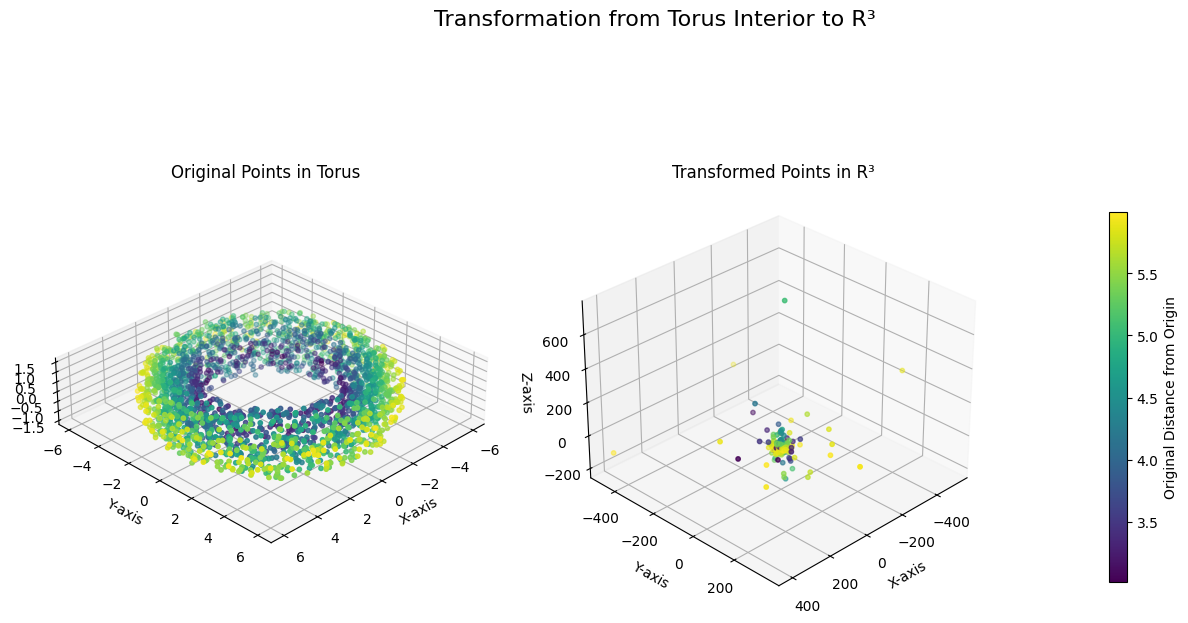

In [15]:
def generate_torus_points(num_points, inner_radius_a, outer_radius_b):
    """Generates random points uniformly distributed inside a torus."""
    R = (inner_radius_a + outer_radius_b) / 2.0
    r = (outer_radius_b - inner_radius_a) / 2.0
    
    points = []
    while len(points) < num_points:
        # Generate points in a bounding box and reject those outside the torus
        x = np.random.uniform(-(R + r), R + r)
        y = np.random.uniform(-(R + r), R + r)
        z = np.random.uniform(-r, r)
        
        # Check if the point is inside the torus
        s = np.sqrt((np.sqrt(x**2 + y**2) - R)**2 + z**2)
        if s < r:
            points.append([x, y, z])
            
    return np.array(points)

# --- Main Execution ---

# 1. Define Torus Geometry and Number of Points
a = 3.0  # Inner radius
b = 6.0  # Outer radius
num_points = 2500

# 2. Generate Original Points
original_points = generate_torus_points(num_points, a, b)

# 3. Transform the Points
transformed_points = np.array([map_torus_to_r3(p, a, b) for p in original_points])

# Use the radial distance for coloring to see the expansion
radial_distance = np.sqrt(original_points[:,0]**2 + original_points[:,1]**2 + original_points[:,2]**2)

# 4. Create the Plots
fig = plt.figure(figsize=(16, 8))

# --- First Plot: Original Torus Points ---
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2],
                       c=radial_distance, cmap='viridis', s=10)
ax1.set_title('Original Points in Torus')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')
ax1.view_init(elev=30, azim=45) # Set a good viewing angle
ax1.set_aspect('equal', 'box') # Enforce equal scaling

# --- Second Plot: Transformed R3 Points ---
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(transformed_points[:, 0], transformed_points[:, 1], transformed_points[:, 2],
                       c=radial_distance, cmap='viridis', s=10)
ax2.set_title('Transformed Points in R³')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')
ax2.view_init(elev=30, azim=45)

# Add a color bar to relate colors to the original radial distance
cbar = fig.colorbar(scatter1, ax=[ax1, ax2], shrink=0.6, pad=0.1)
cbar.set_label('Original Distance from Origin')


plt.suptitle('Transformation from Torus Interior to R³', fontsize=16)
plt.show()

In [16]:
# Use the distance from the central circle (s) for coloring to better show the expansion
R_major = (a + b) / 2.0
s_distances = np.sqrt((np.sqrt(original_points[:,0]**2 + original_points[:,1]**2) - R_major)**2 + original_points[:,2]**2)

# 4. Create the Plotly Figure
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('Original Points in Torus', 'Transformed Points in R³')
)

# --- First Plot: Original Torus Points ---
fig.add_trace(
    go.Scatter3d(
        x=original_points[:, 0],
        y=original_points[:, 1],
        z=original_points[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=s_distances,  # Color by distance from the central axis
            colorscale='Viridis',
            colorbar=dict(title='Distance from Center of Tube'),
            showscale=True
        )
    ),
    row=1, col=1
)

# --- Second Plot: Transformed R3 Points ---
fig.add_trace(
    go.Scatter3d(
        x=transformed_points[:, 0],
        y=transformed_points[:, 1],
        z=transformed_points[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=s_distances,  # Use the same color scale
            colorscale='Viridis',
            showscale=False # Color bar is already shown
        )
    ),
    row=1, col=2
)

# --- Update Layout and Scene Properties ---
fig.update_layout(
    title_text='Transformation from Torus Interior to R³',
    height=700,
    # Make the torus plot have a correct aspect ratio
    scene1=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data' # This ensures the torus is not distorted
    ),
    scene2=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data' # The R3 plot can auto-scale
    )
)

fig.show()

### Inverse trasformation

In [17]:
def map_r3_to_torus(point_r3, inner_radius_a, outer_radius_b):
    """
    Maps a point from R^3 to the interior of a torus.

    This is the inverse of the map_torus_to_r3 function.

    Args:
        point_r3 (tuple or list): The (x', y', z') coordinates of the point in R^3.
        inner_radius_a (float): The inner radius of the target torus.
        outer_radius_b (float): The outer radius of the target torus.

    Returns:
        numpy.ndarray: The transformed (x, y, z) coordinates inside the torus.
    """
    x_prime, y_prime, z_prime = point_r3

    # 1. Calculate the major and minor radii of the torus
    R = (inner_radius_a + outer_radius_b) / 2.0
    r = (outer_radius_b - inner_radius_a) / 2.0

    # Handle the case where the point is on the z-axis to avoid division by zero
    r_xy_prime = np.sqrt(x_prime**2 + y_prime**2)
    if r_xy_prime == 0:
        # For a point on the z-axis, the closest point on the central circle can be (R, 0, 0)
        C = np.array([R, 0, 0])
    else:
        # 2. Find the corresponding point C on the central circle
        C = np.array([R * x_prime / r_xy_prime, R * y_prime / r_xy_prime, 0])

    # 3. Determine the position vector V' relative to the central circle
    P_prime = np.array([x_prime, y_prime, z_prime])
    V_prime = P_prime - C

    # 4. Calculate the distance 's_prime' from the central circle
    s_prime = np.linalg.norm(V_prime)

    # If the point is already on the central circle, it maps to itself.
    if s_prime == 0:
        return P_prime

    # 5. Apply the inverse scaling function (arctangent) to get the compressed distance 's'
    s = (2 * r / np.pi) * np.arctan(s_prime)

    # 6. Construct the transformed point P inside the torus
    # The new point is found by moving from C by the compressed distance 's'
    # in the same direction as V'.
    P = C + s * (V_prime / s_prime)

    return P

In [19]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate random points in R³ (both positive and negative coordinates)
n_points = 10000
x_original = np.random.uniform(-10, 10, n_points)
y_original = np.random.uniform(-10, 10, n_points)
z_original = np.random.uniform(-10, 10, n_points)

print(f"Generated {n_points} random points in R³")
print(f"X range: [{x_original.min():.2f}, {x_original.max():.2f}]")
print(f"Y range: [{y_original.min():.2f}, {y_original.max():.2f}]")
print(f"Z range: [{z_original.min():.2f}, {z_original.max():.2f}]")

inner_radius_a = 1.8980918419589048
outer_radius_b = 9.110752064481275

# Apply the map_r3_to_torus transformation to all points
x_transformed = []
y_transformed = []
z_transformed = []

print("Applying map_r3_to_torus transformation...")
for i in range(n_points):
    point_r3 = [x_original[i], y_original[i], z_original[i]]
    transformed_point = map_r3_to_torus(point_r3, inner_radius_a, outer_radius_b)
    x_transformed.append(transformed_point[0])
    y_transformed.append(transformed_point[1])
    z_transformed.append(transformed_point[2])

x_transformed = np.array(x_transformed)
y_transformed = np.array(y_transformed)
z_transformed = np.array(z_transformed)

print(f"Transformation complete!")
print(f"Transformed X range: [{x_transformed.min():.3f}, {x_transformed.max():.3f}]")
print(f"Transformed Y range: [{y_transformed.min():.3f}, {y_transformed.max():.3f}]")
print(f"Transformed Z range: [{z_transformed.min():.3f}, {z_transformed.max():.3f}]")

Generated 10000 random points in R³
X range: [-10.00, 9.99]
Y range: [-10.00, 10.00]
Z range: [-10.00, 10.00]
Applying map_r3_to_torus transformation...
Transformation complete!
Transformed X range: [-8.565, 8.567]
Transformed Y range: [-8.553, 8.557]
Transformed Z range: [-3.376, 3.377]


In [21]:
# Create side-by-side comparison
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('Original Points in R³', 'Transformed Points in Torus'),
    horizontal_spacing=0.1
)

# Original points
fig.add_trace(
    go.Scatter3d(
        x=x_original,
        y=y_original,
        z=z_original,
        mode='markers',
        marker=dict(size=2, color='red', opacity=0.7),
        name='Original',
        showlegend=False
    ),
    row=1, col=1
)

# Transformed points
fig.add_trace(
    go.Scatter3d(
        x=x_transformed,
        y=y_transformed,
        z=z_transformed,
        mode='markers',
        marker=dict(size=2, color='blue', opacity=0.7),
        name='Transformed',
        showlegend=False
    ),
    row=1, col=2
)

# Update layout for side-by-side view
fig.update_layout(
    title='Side-by-Side Comparison: Original vs Transformed Points',
    width=1200,
    height=600,
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    scene2=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig.show()


#### Visualization of the trasformation base on distance from the center 

In [22]:
# Statistical analysis
print("=== STATISTICAL ANALYSIS ===")
print(f"Torus parameters: inner_radius = {inner_radius_a}, outer_radius = {outer_radius_b}")
print(f"Major radius R = {(inner_radius_a + outer_radius_b) / 2:.2f}")
print(f"Minor radius r = {(outer_radius_b - inner_radius_a) / 2:.2f}")
print()

print("Original points (R³):")
print(f"  Mean: ({x_original.mean():.3f}, {y_original.mean():.3f}, {z_original.mean():.3f})")
print(f"  Std:  ({x_original.std():.3f}, {y_original.std():.3f}, {z_original.std():.3f})")
print(f"  Range: X∈[{x_original.min():.2f}, {x_original.max():.2f}], Y∈[{y_original.min():.2f}, {y_original.max():.2f}], Z∈[{z_original.min():.2f}, {z_original.max():.2f}]")
print()

print("Transformed points (Torus):")
print(f"  Mean: ({x_transformed.mean():.3f}, {y_transformed.mean():.3f}, {z_transformed.mean():.3f})")
print(f"  Std:  ({x_transformed.std():.3f}, {y_transformed.std():.3f}, {z_transformed.std():.3f})")
print(f"  Range: X∈[{x_transformed.min():.3f}, {x_transformed.max():.3f}], Y∈[{y_transformed.min():.3f}, {y_transformed.max():.3f}], Z∈[{z_transformed.min():.3f}, {z_transformed.max():.3f}]")
print()

# Calculate distances from origin
dist_original = np.sqrt(x_original**2 + y_original**2 + z_original**2)
dist_transformed = np.sqrt(x_transformed**2 + y_transformed**2 + z_transformed**2)

print("Distance from origin:")
print(f"  Original: mean={dist_original.mean():.2f}, std={dist_original.std():.2f}, max={dist_original.max():.2f}")
print(f"  Transformed: mean={dist_transformed.mean():.2f}, std={dist_transformed.std():.2f}, max={dist_transformed.max():.2f}")
print()

# Check if points are within torus bounds
R = (inner_radius_a + outer_radius_b) / 2.0
r = (outer_radius_b - inner_radius_a) / 2.0

# For each transformed point, check if it's within the torus
points_in_torus = 0
for i in range(n_points):
    x, y, z = x_transformed[i], y_transformed[i], z_transformed[i]
    # Distance from z-axis
    r_xy = np.sqrt(x**2 + y**2)
    # Distance from the central circle
    distance_from_central_circle = np.sqrt((r_xy - R)**2 + z**2)
    if distance_from_central_circle <= r:
        points_in_torus += 1

print(f"Points within torus bounds: {points_in_torus}/{n_points} ({100*points_in_torus/n_points:.1f}%)")


=== STATISTICAL ANALYSIS ===
Torus parameters: inner_radius = 1.8980918419589048, outer_radius = 9.110752064481275
Major radius R = 5.50
Minor radius r = 3.61

Original points (R³):
  Mean: (-0.117, 0.091, 0.001)
  Std:  (5.752, 5.786, 5.735)
  Range: X∈[-10.00, 9.99], Y∈[-10.00, 10.00], Z∈[-10.00, 10.00]

Transformed points (Torus):
  Mean: (-0.091, 0.075, 0.004)
  Std:  (4.749, 4.775, 2.552)
  Range: X∈[-8.565, 8.567], Y∈[-8.553, 8.557], Z∈[-3.376, 3.377]

Distance from origin:
  Original: mean=9.58, std=2.79, max=16.39
  Transformed: mean=7.07, std=1.36, max=8.84

Points within torus bounds: 10000/10000 (100.0%)


In [23]:
# Advanced visualization with color coding based on distance from origin
fig = go.Figure()

# Add original points with color based on distance from origin
fig.add_trace(go.Scatter3d(
    x=x_original,
    y=y_original,
    z=z_original,
    mode='markers',
    marker=dict(
        size=3,
        color=dist_original,
        colorscale='Reds',
        colorbar=dict(title="Distance from Origin", x=0.02),
        opacity=0.7
    ),
    name='Original Points (R³)',
    text=[f'Original: ({x_original[i]:.2f}, {y_original[i]:.2f}, {z_original[i]:.2f})<br>Distance: {dist_original[i]:.2f}' 
          for i in range(n_points)],
    hovertemplate='%{text}<extra></extra>'
))

# Add transformed points with color based on distance from origin
fig.add_trace(go.Scatter3d(
    x=x_transformed,
    y=y_transformed,
    z=z_transformed,
    mode='markers',
    marker=dict(
        size=3,
        color=dist_transformed,
        colorscale='Blues',
        colorbar=dict(title="Distance from Origin", x=0.98),
        opacity=0.7
    ),
    name='Transformed Points (Torus)',
    text=[f'Transformed: ({x_transformed[i]:.3f}, {y_transformed[i]:.3f}, {z_transformed[i]:.3f})<br>Distance: {dist_transformed[i]:.3f}' 
          for i in range(n_points)],
    hovertemplate='%{text}<extra></extra>'
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot: Random Points with Distance-Based Color Coding<br>' +
          f'<sub>Red points: Original R³ points | Blue points: Transformed torus points | ' +
          f'Torus: R={R:.1f}, r={r:.1f}</sub>',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1200,
    height=800,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


#### Generate normal distributed random points in a toroid and mapping to $R^3$

In [26]:
# =============================================================================
# GAUSSIAN NORMAL DISTRIBUTION ANALYSIS
# =============================================================================

def generate_gaussian_points(n_points, std_deviation=2.0, center=(0, 0, 0)):
    """
    Generate points using Gaussian normal distribution.
    
    Args:
        n_points (int): Number of points to generate
        std_deviation (float): Standard deviation for the Gaussian distribution
        center (tuple): Center point (x, y, z) for the distribution
    
    Returns:
        tuple: (x, y, z) arrays of generated points
    """
    cx, cy, cz = center
    
    # Generate points using normal distribution
    x_gaussian = np.random.normal(cx, std_deviation, n_points)
    y_gaussian = np.random.normal(cy, std_deviation, n_points)
    z_gaussian = np.random.normal(cz, std_deviation, n_points)
    
    return x_gaussian, y_gaussian, z_gaussian

# Generate Gaussian points with standard deviation of 2
n_points_gaussian = 10000
std_dev = 10.0
x_gaussian = np.random.normal(0, std_dev, n_points_gaussian)
y_gaussian = np.random.normal(0, std_dev, n_points_gaussian)
z_gaussian = np.random.normal(0, std_dev, n_points_gaussian)

print(f"Generated {n_points_gaussian} points using Gaussian normal distribution")
print(f"Standard deviation: {std_dev}")
print(f"X range: [{x_gaussian.min():.2f}, {x_gaussian.max():.2f}]")
print(f"Y range: [{y_gaussian.min():.2f}, {y_gaussian.max():.2f}]")
print(f"Z range: [{z_gaussian.min():.2f}, {z_gaussian.max():.2f}]")
print(f"X mean: {x_gaussian.mean():.3f}, std: {x_gaussian.std():.3f}")
print(f"Y mean: {y_gaussian.mean():.3f}, std: {y_gaussian.std():.3f}")
print(f"Z mean: {z_gaussian.mean():.3f}, std: {z_gaussian.std():.3f}")

# Apply the map_r3_to_torus transformation to Gaussian points
x_gaussian_transformed = []
y_gaussian_transformed = []
z_gaussian_transformed = []

print("Applying map_r3_to_torus transformation to Gaussian points...")
for i in range(n_points_gaussian):
    point_r3 = [x_gaussian[i], y_gaussian[i], z_gaussian[i]]
    transformed_point = map_r3_to_torus(point_r3, inner_radius_a, outer_radius_b)
    x_gaussian_transformed.append(transformed_point[0])
    y_gaussian_transformed.append(transformed_point[1])
    z_gaussian_transformed.append(transformed_point[2])

x_gaussian_transformed = np.array(x_gaussian_transformed)
y_gaussian_transformed = np.array(y_gaussian_transformed)
z_gaussian_transformed = np.array(z_gaussian_transformed)

print(f"Transformed X range: [{x_gaussian_transformed.min():.3f}, {x_gaussian_transformed.max():.3f}]")
print(f"Transformed Y range: [{y_gaussian_transformed.min():.3f}, {y_gaussian_transformed.max():.3f}]")
print(f"Transformed Z range: [{z_gaussian_transformed.min():.3f}, {z_gaussian_transformed.max():.3f}]")



Generated 10000 points using Gaussian normal distribution
Standard deviation: 10.0
X range: [-36.88, 38.30]
Y range: [-37.05, 37.66]
Z range: [-37.83, 42.02]
X mean: 0.024, std: 9.966
Y mean: -0.099, std: 10.020
Z mean: 0.190, std: 9.905
Applying map_r3_to_torus transformation to Gaussian points...
Transformed X range: [-8.995, 9.011]
Transformed Y range: [-9.000, 9.009]
Transformed Z range: [-3.545, 3.535]


In [27]:
# Create side-by-side comparison for Gaussian points
fig_gaussian_compare = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('Original Gaussian Points (R³)', 'Transformed Gaussian Points (Torus)'),
    horizontal_spacing=0.1
)

# Original Gaussian points
fig_gaussian_compare.add_trace(
    go.Scatter3d(
        x=x_gaussian,
        y=y_gaussian,
        z=z_gaussian,
        mode='markers',
        marker=dict(size=2, color='green', opacity=0.7),
        name='Original Gaussian',
        showlegend=False
    ),
    row=1, col=1
)

# Transformed Gaussian points
fig_gaussian_compare.add_trace(
    go.Scatter3d(
        x=x_gaussian_transformed,
        y=y_gaussian_transformed,
        z=z_gaussian_transformed,
        mode='markers',
        marker=dict(size=2, color='purple', opacity=0.7),
        name='Transformed Gaussian',
        showlegend=False
    ),
    row=1, col=2
)

# Update layout for side-by-side view
fig_gaussian_compare.update_layout(
    title=f'Side-by-Side Comparison: Gaussian Normal Distribution (σ={std_dev})',
    width=1200,
    height=600,
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    scene2=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig_gaussian_compare.show()


In [28]:
# Advanced comparison visualization with all four datasets
fig_comparison = go.Figure()

# Add uniform original points
fig_comparison.add_trace(go.Scatter3d(
    x=x_original,
    y=y_original,
    z=z_original,
    mode='markers',
    marker=dict(
        size=2,
        color='red',
        opacity=0.5
    ),
    name='Uniform Original (R³)',
    text=[f'Uniform Original: ({x_original[i]:.2f}, {y_original[i]:.2f}, {z_original[i]:.2f})' 
          for i in range(n_points)],
    hovertemplate='%{text}<extra></extra>'
))

# Add uniform transformed points
fig_comparison.add_trace(go.Scatter3d(
    x=x_transformed,
    y=y_transformed,
    z=z_transformed,
    mode='markers',
    marker=dict(
        size=2,
        color='blue',
        opacity=0.5
    ),
    name='Uniform Transformed (Torus)',
    text=[f'Uniform Transformed: ({x_transformed[i]:.3f}, {y_transformed[i]:.3f}, {z_transformed[i]:.3f})' 
          for i in range(n_points)],
    hovertemplate='%{text}<extra></extra>'
))

# Add Gaussian original points
fig_comparison.add_trace(go.Scatter3d(
    x=x_gaussian,
    y=y_gaussian,
    z=z_gaussian,
    mode='markers',
    marker=dict(
        size=2,
        color='green',
        opacity=0.5
    ),
    name='Gaussian Original (R³)',
    text=[f'Gaussian Original: ({x_gaussian[i]:.2f}, {y_gaussian[i]:.2f}, {z_gaussian[i]:.2f})' 
          for i in range(n_points_gaussian)],
    hovertemplate='%{text}<extra></extra>'
))

# Add Gaussian transformed points
fig_comparison.add_trace(go.Scatter3d(
    x=x_gaussian_transformed,
    y=y_gaussian_transformed,
    z=z_gaussian_transformed,
    mode='markers',
    marker=dict(
        size=2,
        color='purple',
        opacity=0.5
    ),
    name='Gaussian Transformed (Torus)',
    text=[f'Gaussian Transformed: ({x_gaussian_transformed[i]:.3f}, {y_gaussian_transformed[i]:.3f}, {z_gaussian_transformed[i]:.3f})' 
          for i in range(n_points_gaussian)],
    hovertemplate='%{text}<extra></extra>'
))

# Update layout
fig_comparison.update_layout(
    title='Complete Comparison: Uniform vs Gaussian Distributions<br>' +
          f'<sub>Red: Uniform Original | Blue: Uniform Transformed | Green: Gaussian Original (σ={std_dev}) | Purple: Gaussian Transformed</sub>',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1200,
    height=800,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig_comparison.show()
